# Week 1 (May 14 - 20)

### Note about the images
In both images: 
+ Size 2048x2048 (size of the CCD), 30 subs stacked together for each
+ Some sorts of streaks in the middle region (damages to the CCD?)
+ Bad column from x $\approx$ 895-960
+ Some sorts of surrounding dust in the outer region of the CCD

In image 152, the bad columns appeared different over time, as opposed to image 162

### Plot last images of every Cube

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
%matplotlib inline
from astropy.io import fits
from astropy.wcs import WCS
import glob

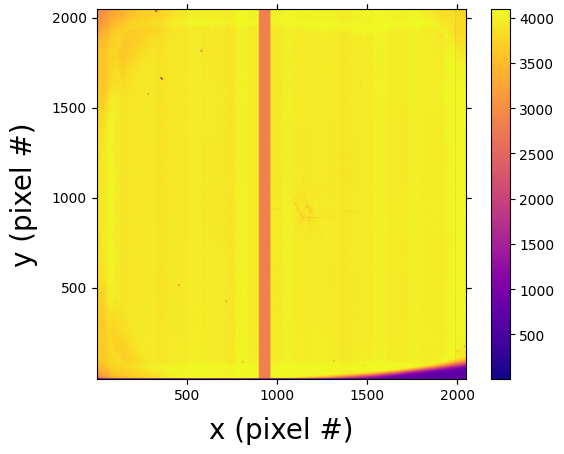

In [24]:
# Extract image data & header and parse the WCS information
image_1_data = fits.getdata("images/test/lm_260429_000152.fits")
image_1_header = fits.getheader("images/test/lm_260429_000152.fits")
wcs = WCS(image_1_header)

fig, ax = plt.subplots(subplot_kw=(dict(projection=wcs,slices=(30,"x","y"))))
color_ax = ax.imshow(image_1_data[29,:,:],origin="lower",cmap="plasma")
fig.colorbar(color_ax, ax=ax)
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

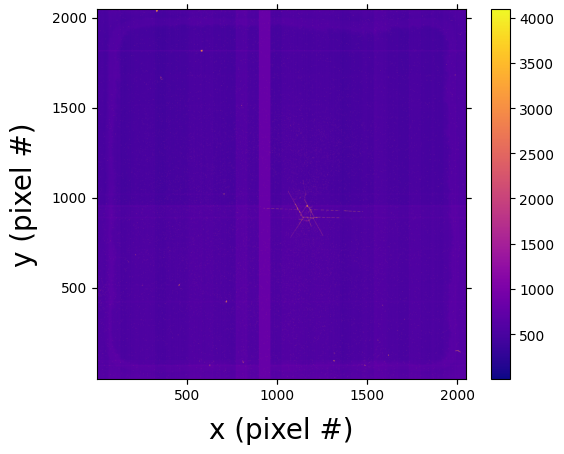

In [25]:
image_2_data = fits.getdata("images/test/lm_260429_000162.fits")
image_2_header = fits.getheader("images/test/lm_260429_000162.fits")
wcs = WCS(image_2_header)

fig, ax = plt.subplots(subplot_kw=(dict(projection=wcs,slices=(30,"x","y"))))
color_ax = ax.imshow(image_2_data[29,:,:],origin="lower",cmap="plasma")
fig.colorbar(color_ax, ax=ax)
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

## Compute the difference between two images and save to new FITS file

In [4]:
diff = image_2_data-image_1_data

diff_image = fits.PrimaryHDU(diff)
diff_image.writeto("diff.fits", overwrite=True)

### Note about difference image:
More vignettes at the corners of the image (non-uniform as in the bottom right corner)

Streaks in the middle region of the images remain 



# Week 2 (May 21 - 27)

## 1) Make difference images

### a) Linearity fast

Take the average of all light frames to create one combined light image

In [5]:
# Call in all file names for linearity images
light_filenames = glob.glob('images\\fast_light\\*')

# Create an empty directory store the data from light frames
light_frames = [None] * len(light_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(light_filenames):
    image_data = fits.getdata(filename)
    light_frames[i] = image_data
light_frames = np.array(light_frames)

# Create the combined image
superlight = np.average(light_frames,axis=0)
print(superlight.shape)

(30, 2048, 2048)


Save the combined light image to a new FITS file

In [6]:
# Extract the header of the first light frame
info_light = fits.getheader(light_filenames[0])

# Add reduction notes to header
lights_hdr = fits.Header()
lights_hdr = info_light
lights_hdr["Reduction"] = "Averaging 10 light frames with exposure of 3212.42s each"

# Write the combined light image data with updated header to a new FITS file
combined_light = fits.PrimaryHDU(data=superlight, header=lights_hdr)
combined_light.writeto("images/fast_combined_light.fits", overwrite=True)

Take the average of all dark frames to create one combined dark image

In [7]:
# Call in all file names for linearity images
dark_filenames = glob.glob('images\\fast_dark\\*')

# Create an empty directory store the data from light frames
dark_frames = [None] * len(dark_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(dark_filenames):
    image_data = fits.getdata(filename)
    dark_frames[i] = image_data
dark_frames = np.array(dark_frames)

# Create the combined image
superdark = np.average(dark_frames,axis=0)
print(superdark.shape)

(30, 2048, 2048)


Save the combined dark image to a new FITS file

In [8]:
# Extract the header of the first dark frame
info_dark = fits.getheader(dark_filenames[0])

# Add reduction notes to header
darks_hdr = fits.Header()
darks_hdr = info_dark
darks_hdr["Reduction"] = "Averaging 10 dark frames with exposure of 3212.42s each"

# Write the combined dark image data with updated header to a new FITS file
combined_dark = fits.PrimaryHDU(data=superdark, header=darks_hdr)
combined_light.writeto("images/fast_combined_dark.fits", overwrite=True)

Compute the difference between two combined images and save to new FITS file

In [9]:
# Compute the difference
diff = superlight - superdark

# Merge header from combined light frame and add reduction notes
diffs_hdr = fits.getheader("images/fast_combined_light.fits")
diffs_hdr["Reduction"] += " and subtract the combined dark frame from the combined light frame"

# Write the difference image data with updated header to a new FITS file
combined_diff = fits.PrimaryHDU(data=diff, header=diffs_hdr)
combined_diff.writeto("images/fast_diff.fits", overwrite=True)

### b) Linearity medium

Take the average of all light frames to create one combined light image

In [10]:
# Call in all file names for linearity images
light_filenames = glob.glob('images\\medium_light\\*')

# Create an empty directory store the data from light frames
light_frames = [None] * len(light_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(light_filenames):
    image_data = fits.getdata(filename)
    light_frames[i] = image_data
light_frames = np.array(light_frames)

# Create the combined image
superlight = np.average(light_frames,axis=0)
print(superlight.shape)

(30, 2048, 2048)


Save the combined light image to a new FITS file

In [11]:
# Extract the header of the first light frame
info_light = fits.getheader(light_filenames[0])

# Add reduction notes to header
lights_hdr = fits.Header()
lights_hdr = info_light
lights_hdr["Reduction"] = "Averaging 11 light frames with exposure of 29013.8s each"

# Write the combined light image data with updated header to a new FITS file
combined_light = fits.PrimaryHDU(data=superlight, header=lights_hdr)
combined_light.writeto("images/medium_combined_light.fits", overwrite=True)

Take the average of all dark frames to create one combined dark image

In [12]:
# Call in all file names for linearity images
dark_filenames = glob.glob('images\\medium_dark\\*')

# Create an empty directory store the data from light frames
dark_frames = [None] * len(dark_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(dark_filenames):
    image_data = fits.getdata(filename)
    dark_frames[i] = image_data
dark_frames = np.array(dark_frames)

# Create the combined image
superdark = np.average(dark_frames,axis=0)
print(superdark.shape)

(30, 2048, 2048)


Save the combined dark image to a new FITS file

In [13]:
# Extract the header of the first dark frame
info_dark = fits.getheader(dark_filenames[0])

# Add reduction notes to header
darks_hdr = fits.Header()
darks_hdr = info_dark
darks_hdr["Reduction"] = "Averaging 10 dark frames with exposure of 29013.8s each"

# Write the combined dark image data with updated header to a new FITS file
combined_dark = fits.PrimaryHDU(data=superdark, header=darks_hdr)
combined_dark.writeto("images/medium_combined_dark.fits", overwrite=True)

Compute the difference between two combined images and save to new FITS file

In [14]:
# Compute the difference
diff = superlight - superdark

# Merge header from combined light frame and add reduction notes
diffs_hdr = fits.getheader("images/medium_combined_light.fits")
diffs_hdr["Reduction"] += " and subtract the combined dark frame from the combined light frame"

# Write the difference image data with updated header to a new FITS file
combined_diff = fits.PrimaryHDU(data=diff, header=diffs_hdr)
combined_diff.writeto("images/medium_diff.fits", overwrite=True)

### c) Linearity slow

Take the average of all light frames to create one combined light image

In [15]:
# Call in all file names for linearity images
light_filenames = glob.glob('images\\slow_light\\*')

# Create an empty directory store the data from light frames
light_frames = [None] * len(light_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(light_filenames):
    image_data = fits.getdata(filename)
    light_frames[i] = image_data
light_frames = np.array(light_frames)

# Create the combined image
superlight = np.average(light_frames,axis=0)
print(superlight.shape)

(30, 2048, 2048)


Save the combined light image to a new FITS file

In [16]:
# Extract the header of the first light frame
info_light = fits.getheader(light_filenames[0])

# Add reduction notes to header
lights_hdr = fits.Header()
lights_hdr = info_light
lights_hdr["Reduction"] = "Averaging 10 light frames with exposure of 87041.5s each"

# Write the combined light image data with updated header to a new FITS file
combined_light = fits.PrimaryHDU(data=superlight, header=lights_hdr)
combined_light.writeto("images/slow_combined_light.fits", overwrite=True)

Take the average of all dark frames to create one combined dark image

In [17]:
# Call in all file names for linearity images
dark_filenames = glob.glob('images\\slow_dark\\*')

# Create an empty directory store the data from light frames
dark_frames = [None] * len(dark_filenames)

# Extract data from our set of light frames
for i, filename in enumerate(dark_filenames):
    image_data = fits.getdata(filename)
    dark_frames[i] = image_data
dark_frames = np.array(dark_frames)

# Create the combined image
superdark = np.average(dark_frames,axis=0)
print(superdark.shape)

(30, 2048, 2048)


Save the combined dark image to a new FITS file

In [18]:
# Extract the header of the first dark frame
info_dark = fits.getheader(dark_filenames[0])

# Add reduction notes to header
darks_hdr = fits.Header()
darks_hdr = info_dark
darks_hdr["Reduction"] = "Averaging 10 dark frames with exposure of 87041.5s each"

# Write the combined dark image data with updated header to a new FITS file
combined_dark = fits.PrimaryHDU(data=superdark, header=darks_hdr)
combined_dark.writeto("images/slow_combined_dark.fits", overwrite=True)

Compute the difference between two combined images and save to new FITS file

In [19]:
# Compute the difference
diff = superlight - superdark

# Merge header from combined light frame and add reduction notes
diffs_hdr = fits.getheader("images/medium_combined_light.fits")
diffs_hdr["Reduction"] += " and subtract the combined dark frame from the combined light frame"

# Write the difference image data with updated header to a new FITS file
combined_diff = fits.PrimaryHDU(data=diff, header=diffs_hdr)
combined_diff.writeto("images/slow_diff.fits", overwrite=True)

## 2) Compute statistics and plot results

### a) Plot the "clean" region to be examined

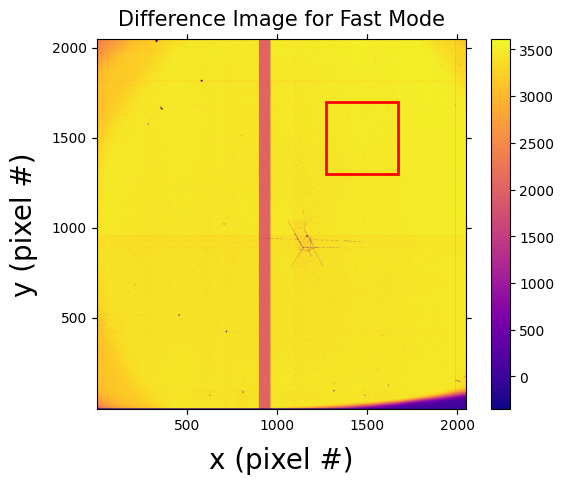

In [42]:
# Extract data and header from the fast difference image
test_data = fits.getdata("images/fast_diff.fits")
test_header = fits.getheader("images/fast_diff.fits")
wcs = WCS(test_header)

# Plot the fast difference image
fig, ax = plt.subplots(subplot_kw=(dict(projection=wcs,slices=(30,"x","y"))))
color_ax = ax.imshow(test_data[29,:,:],origin="lower",cmap="plasma")
fig.colorbar(color_ax, ax=ax)

# Plot the region of interest
rect = Rectangle((1270, 1300), 400, 400, edgecolor='red', facecolor='none', lw=2)
ax.add_patch(rect)

plt.title("Difference Image for Fast Mode", size = 15, y=1.015)
plt.xlabel('x (pixel #)', size = 20)
plt.ylabel('y (pixel #)', size = 20)
plt.show()

Extract data within the region of interest from all the combined and difference images

In [43]:
# Fast mode
fast_light = fits.getdata("images/fast_combined_light.fits")[:,1270:1670,1300:1700]
fast_dark = fits.getdata("images/fast_combined_dark.fits")[:,1270:1670,1300:1700]
fast_diff = fits.getdata("images/fast_diff.fits")[:,1270:1670,1300:1700]

# Medium mode
medium_light = fits.getdata("images/medium_combined_light.fits")[:,1270:1670,1300:1700]
medium_dark = fits.getdata("images/medium_combined_dark.fits")[:,1270:1670,1300:1700]
medium_diff = fits.getdata("images/medium_diff.fits")[:,1270:1670,1300:1700]

# Slow mode
slow_light = fits.getdata("images/slow_combined_light.fits")[:,1270:1670,1300:1700]
slow_dark = fits.getdata("images/slow_combined_dark.fits")[:,1270:1670,1300:1700]
slow_diff = fits.getdata("images/slow_diff.fits")[:,1270:1670,1300:1700]

### b) Compute and plot the mean of pixel values in the chosen region

All modes together (for general perspective)

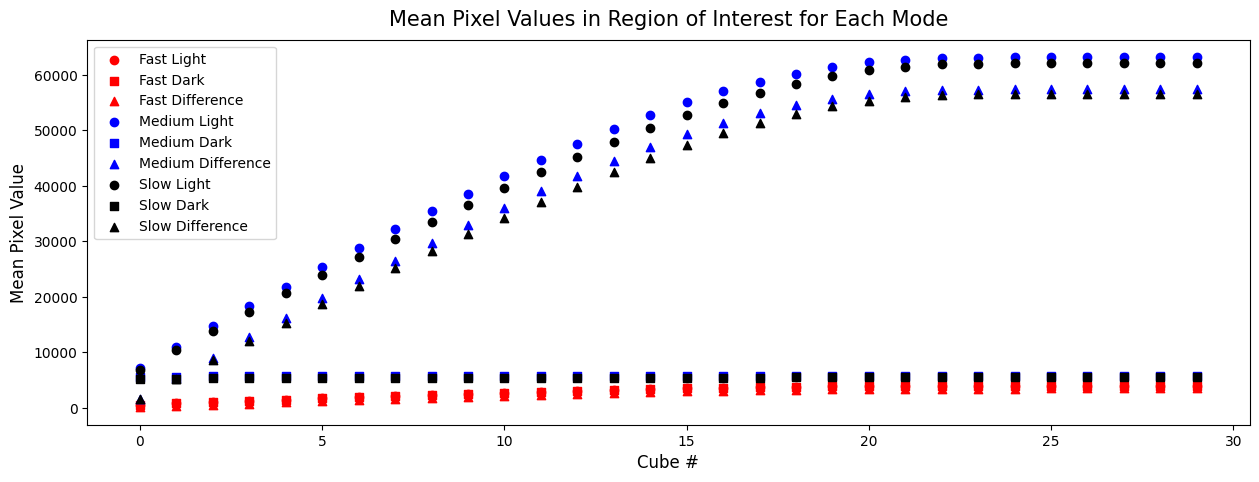

In [46]:
# Group data objects into a list for easy iteration
# Each tuple: (mode_name, data_3d, color)
modes = [
    ('Fast', fast_light, fast_dark, fast_diff, 'red'),
    ('Medium', medium_light, medium_dark, medium_diff, 'blue'),
    ('Slow', slow_light, slow_dark, slow_diff, 'black')
]
markers = ['o', 's', '^']

plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Each Mode", size=15, y=1.015)
plt.xlabel("Cube #", size=12)
plt.ylabel("Mean Pixel Value", size=12)

# Plotting loop
for i in range(30):
    for name, light, dark, diff, color in modes:
        # Dictionary mapping frame names to their respective data slices
        frame_data = {'Light': light[i, :, :], 'Dark': dark[i, :, :], 'Difference': diff[i, :, :]}
        
        for j, (frame_type, data_slice) in enumerate(frame_data.items()):
            plt.scatter(i, np.mean(data_slice), 
                        marker=markers[j], 
                        color=color, 
                        label=f'{name} {frame_type}' if i == 0 else "")

plt.legend()
plt.show()

Fast Mode

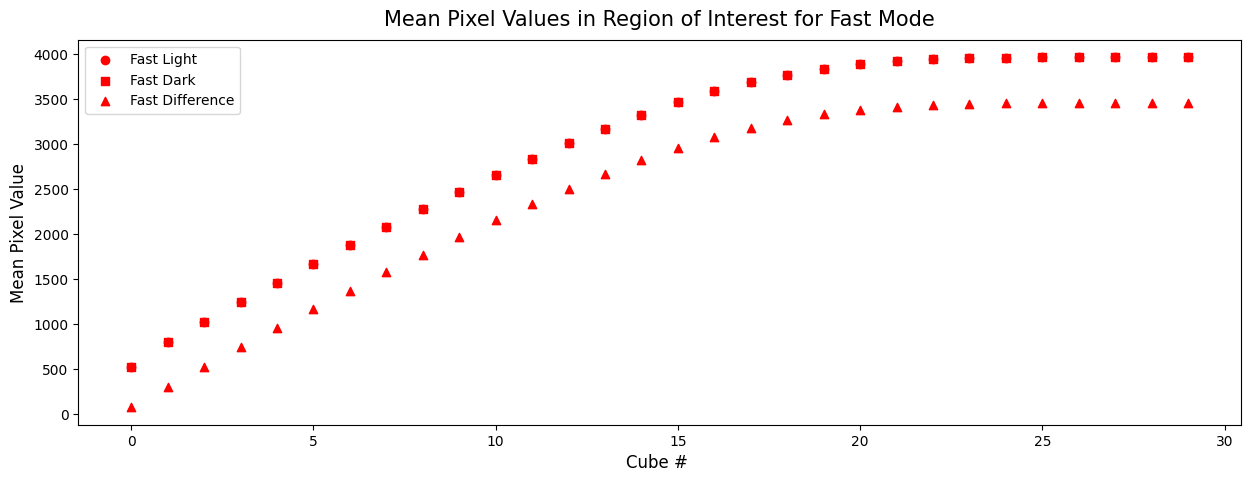

In [47]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Fast Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Mean Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of fast mode
    fast_light_mean = np.mean(fast_light[i, :, :])
    fast_dark_mean = np.mean(fast_dark[i, :, :])
    fast_diff_mean = np.mean(fast_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, fast_light_mean, marker=markers[0], color="red", label='Fast Light' if i == 0 else "")
    plt.scatter(i, fast_dark_mean, marker=markers[1], color="red", label='Fast Dark' if i == 0 else "")
    plt.scatter(i, fast_diff_mean, marker=markers[2], color="red", label='Fast Difference' if i == 0 else "")

plt.legend()
plt.show()

Medium Mode

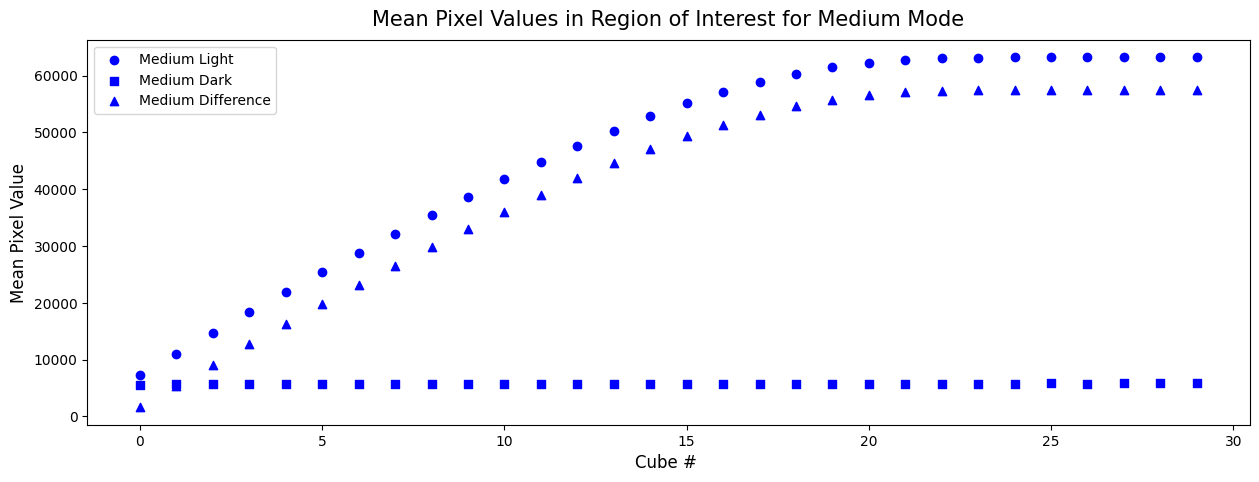

In [48]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Medium Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Mean Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of medium mode
    medium_light_mean = np.mean(medium_light[i, :, :])
    medium_dark_mean = np.mean(medium_dark[i, :, :])
    medium_diff_mean = np.mean(medium_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, medium_light_mean, marker=markers[0], color="blue", label='Medium Light' if i == 0 else "")
    plt.scatter(i, medium_dark_mean, marker=markers[1], color="blue", label='Medium Dark' if i == 0 else "")
    plt.scatter(i, medium_diff_mean, marker=markers[2], color="blue", label='Medium Difference' if i == 0 else "")

plt.legend()
plt.show()

Slow Mode

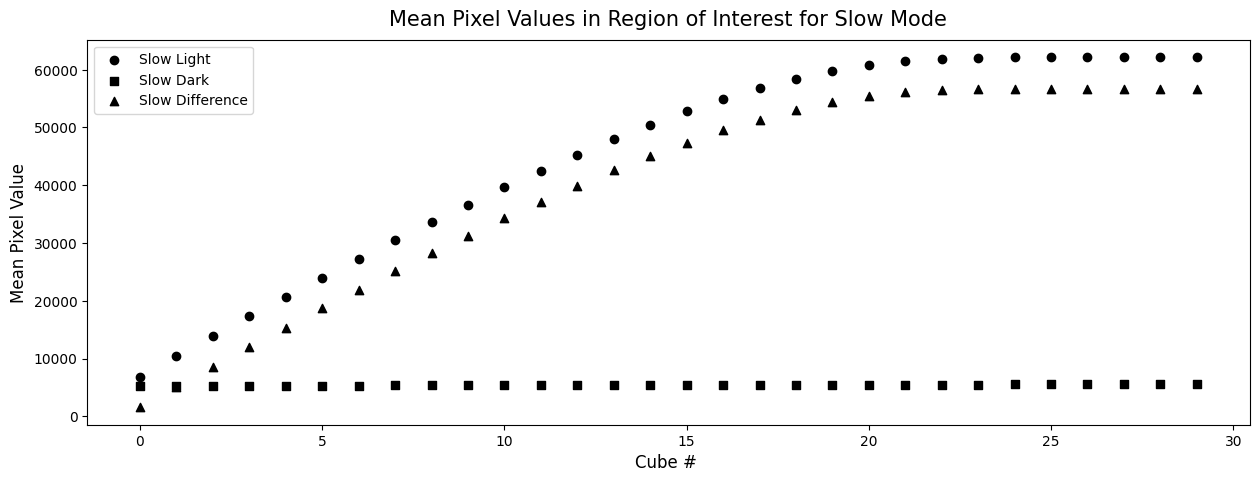

In [49]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Mean Pixel Values in Region of Interest for Slow Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Mean Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of slow mode
    slow_light_mean = np.mean(slow_light[i, :, :])
    slow_dark_mean = np.mean(slow_dark[i, :, :])
    slow_diff_mean = np.mean(slow_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, slow_light_mean, marker=markers[0], color="black", label='Slow Light' if i == 0 else "")
    plt.scatter(i, slow_dark_mean, marker=markers[1], color="black", label='Slow Dark' if i == 0 else "")
    plt.scatter(i, slow_diff_mean, marker=markers[2], color="black", label='Slow Difference' if i == 0 else "")

plt.legend()
plt.show()

### c) Compute and plot the median of pixel values in the chosen region

All modes together

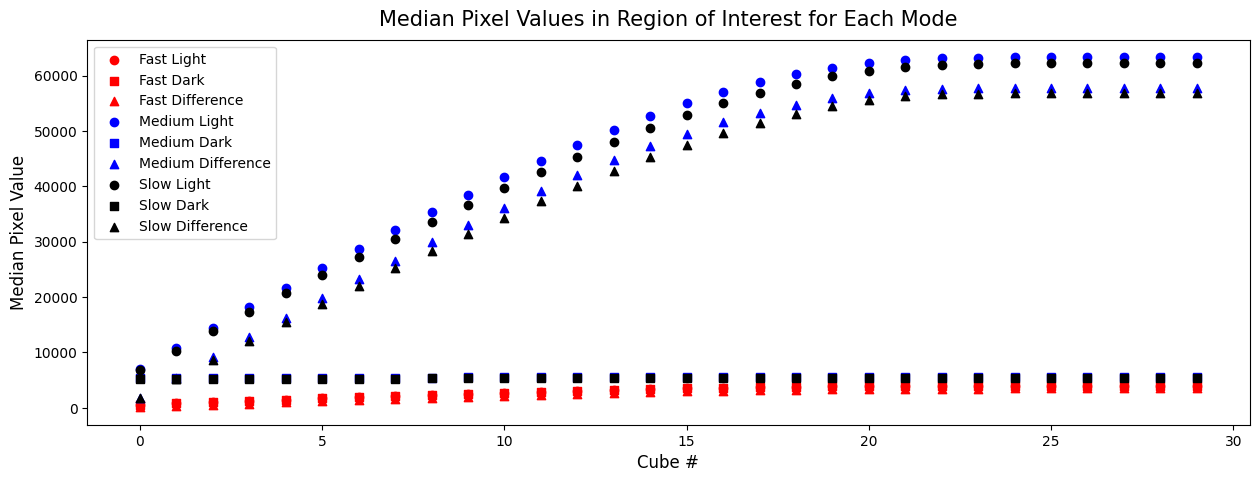

In [50]:
# Group data objects into a list for easy iteration
# Each tuple: (mode_name, data_3d, color)
modes = [
    ('Fast', fast_light, fast_dark, fast_diff, 'red'),
    ('Medium', medium_light, medium_dark, medium_diff, 'blue'),
    ('Slow', slow_light, slow_dark, slow_diff, 'black')
]
markers = ['o', 's', '^']

plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Each Mode", size=15, y=1.015)
plt.xlabel("Cube #", size=12)
plt.ylabel("Median Pixel Value", size=12)

# Plotting loop
for i in range(30):
    for name, light, dark, diff, color in modes:
        # Dictionary mapping frame names to their respective data slices
        frame_data = {'Light': light[i, :, :], 'Dark': dark[i, :, :], 'Difference': diff[i, :, :]}
        
        for j, (frame_type, data_slice) in enumerate(frame_data.items()):
            plt.scatter(i, np.median(data_slice), 
                        marker=markers[j], 
                        color=color, 
                        label=f'{name} {frame_type}' if i == 0 else "")

plt.legend()
plt.show()

Fast Mode

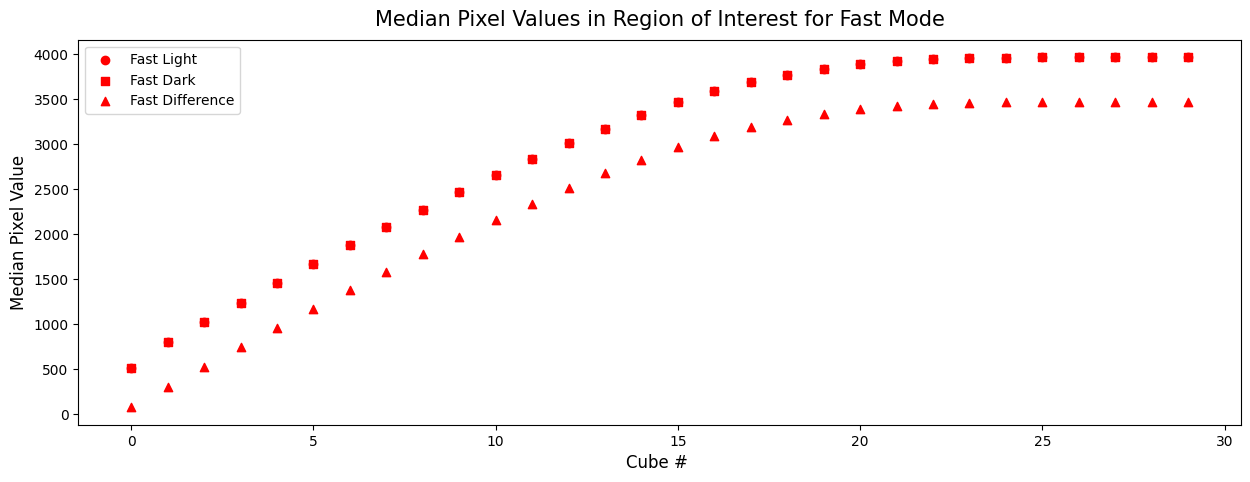

In [51]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Fast Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Median Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of fast mode
    fast_light_mean = np.median(fast_light[i, :, :])
    fast_dark_mean = np.median(fast_dark[i, :, :])
    fast_diff_mean = np.median(fast_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, fast_light_mean, marker=markers[0], color="red", label='Fast Light' if i == 0 else "")
    plt.scatter(i, fast_dark_mean, marker=markers[1], color="red", label='Fast Dark' if i == 0 else "")
    plt.scatter(i, fast_diff_mean, marker=markers[2], color="red", label='Fast Difference' if i == 0 else "")

plt.legend()
plt.show()

Medium Mode

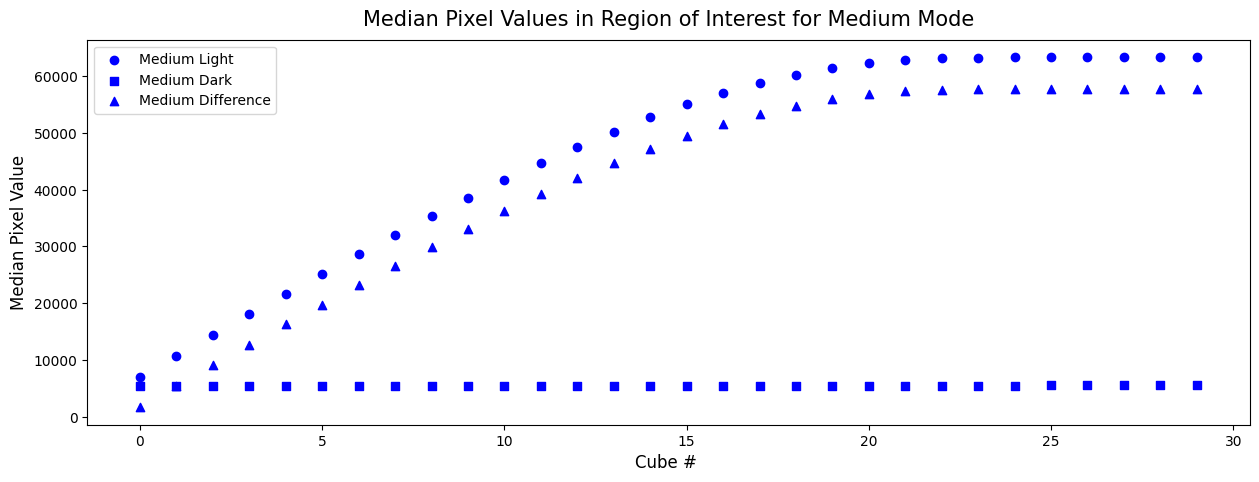

In [52]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Medium Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Median Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of medium mode
    medium_light_mean = np.median(medium_light[i, :, :])
    medium_dark_mean = np.median(medium_dark[i, :, :])
    medium_diff_mean = np.median(medium_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, medium_light_mean, marker=markers[0], color="blue", label='Medium Light' if i == 0 else "")
    plt.scatter(i, medium_dark_mean, marker=markers[1], color="blue", label='Medium Dark' if i == 0 else "")
    plt.scatter(i, medium_diff_mean, marker=markers[2], color="blue", label='Medium Difference' if i == 0 else "")

plt.legend()
plt.show()

Slow Mode

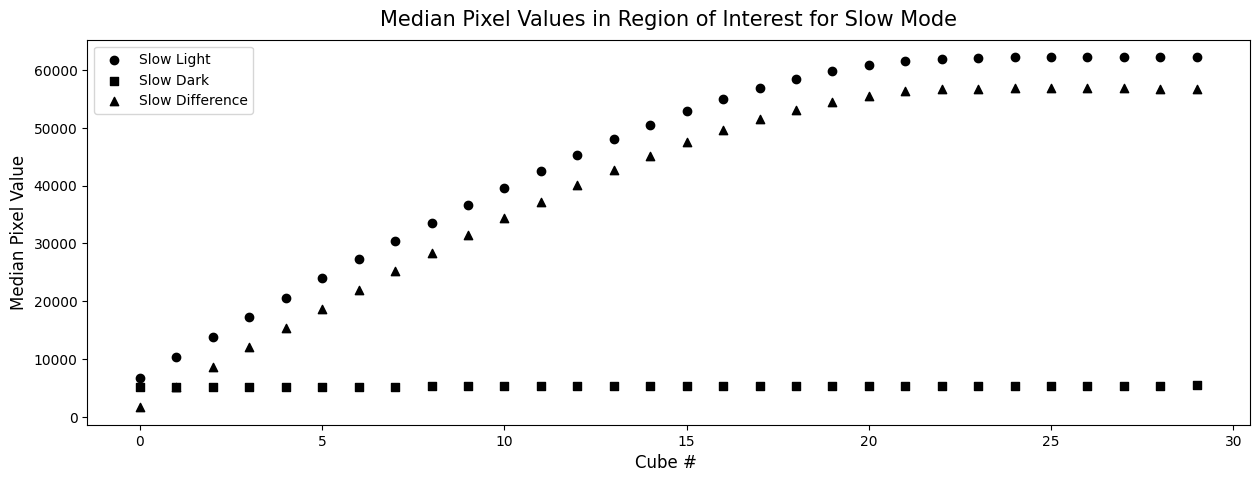

In [53]:
# Set up the figure and axes
plt.figure(figsize=(15, 5))
plt.title("Median Pixel Values in Region of Interest for Slow Mode", size = 15, y=1.015)
plt.xlabel("Cube # ", size = 12)
plt.ylabel("Median Pixel Value", size = 12)

# Define the marker color for each frame type
markers = ['o', 's', '^'] ## Circle for light, square for dark, triangle for difference

# Iterate over all the Cubes and calculate the mean pixel value in the region of interest
for i in range(0,30,1):
    # Compute the mean pixel value in the region of interest for the three frames of slow mode
    slow_light_mean = np.median(slow_light[i, :, :])
    slow_dark_mean = np.median(slow_dark[i, :, :])
    slow_diff_mean = np.median(slow_diff[i, :, :])
    
    # Plot the mean pixel values
    plt.scatter(i, slow_light_mean, marker=markers[0], color="black", label='Slow Light' if i == 0 else "")
    plt.scatter(i, slow_dark_mean, marker=markers[1], color="black", label='Slow Dark' if i == 0 else "")
    plt.scatter(i, slow_diff_mean, marker=markers[2], color="black", label='Slow Difference' if i == 0 else "")

plt.legend()
plt.show()